# 04 — Decision Trees: Complete Guide

**Learning sequence:** Problem → Intuition → Splitting Mathematics → Tree Structure → From Scratch → Scikit-learn → Evaluation → Pruning → Failure Cases

This notebook develops a practical and conceptual understanding of Decision Tree models. It focuses on **classification** and uses the breast cancer dataset included with scikit-learn. The dataset is used for educational modeling—not as a clinical diagnostic system.

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain how a Decision Tree makes predictions.
- Distinguish classification trees from regression trees.
- Understand nodes, branches, leaves, depth, and decision rules.
- Explain Gini impurity, entropy, information gain, and split selection.
- Train and inspect a tree using scikit-learn.
- Evaluate a classifier with a confusion matrix, precision, recall, F1, and ROC-AUC.
- Recognize overfitting and control it with tree hyperparameters and pruning.
- Interpret feature importance and decision paths responsibly.
- Build a simple educational decision-tree splitter from scratch.
- Avoid data leakage and understand limitations of tree-based models.

In [1]:
# Import libraries used throughout the notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a random seed for reproducible examples.
RANDOM_STATE = 42

## 1. What Is a Decision Tree?

A Decision Tree predicts an outcome by applying a sequence of feature-based questions.

For classification, an internal node asks a question such as `mean radius <= threshold`. Depending on the answer, an observation follows one branch or another. A leaf node returns a class prediction (and may also provide class probabilities).

**Core terms**

- **Root:** the first node in the tree.
- **Decision/internal node:** a node that splits observations.
- **Branch:** an outcome of a split.
- **Leaf:** a terminal node that produces a prediction.
- **Depth:** the number of edges from the root to a node.
- **Feature:** an input variable used to make decisions.
- **Target:** the label the model is learning to predict.

Trees can model nonlinear relationships and feature interactions without requiring feature scaling. They can, however, overfit when allowed to grow too complex.

## 2. Classification vs Regression Trees

- A **classification tree** predicts a category, such as benign or malignant.
- A **regression tree** predicts a numerical value, such as a price.

Classification trees commonly select splits using criteria such as Gini impurity or entropy. Regression trees commonly choose splits that reduce target variance or squared error.

This notebook concentrates on classification, then briefly demonstrates regression.

In [2]:
# Draw a tiny conceptual example using readable rule text.
example_rules = [
    ("Root", "mean radius <= threshold?"),
    ("Left branch", "yes → follow left child"),
    ("Right branch", "no → follow right child"),
    ("Leaf", "predict a class")
]

for part, rule in example_rules:
    # Print each conceptual component of a decision tree.
    print(f"{part}: {rule}")

Root: mean radius <= threshold?
Left branch: yes → follow left child
Right branch: no → follow right child
Leaf: predict a class


## 3. How Does a Tree Choose a Split?

A useful split creates child groups that are more homogeneous in their target labels than the parent group.

### Gini impurity

For class proportions $p_1, p_2, \ldots, p_K$:

$$
Gini = 1 - \sum_{k=1}^{K} p_k^2
$$

Gini is zero when a node contains only one class.

### Entropy

$$
H = -\sum_{k=1}^{K} p_k \log_2(p_k)
$$

Entropy is also zero for a pure node. It increases as class labels become more mixed.

### Information gain

$$
IG = H(\text{parent}) -
\sum_j \frac{n_j}{n} H(\text{child}_j)
$$

The weighted child impurity accounts for the number of observations in each child. A split is useful when it reduces impurity.

**Important:** Gini and entropy are split criteria, not final model-performance metrics.

In [3]:
# Calculate Gini impurity and entropy for a binary node.
def gini_impurity(labels):
    # Count the proportion of each class in this node.
    _, counts = np.unique(labels, return_counts=True)
    probabilities = counts / counts.sum()

    # A pure node has Gini impurity equal to zero.
    return 1.0 - np.sum(probabilities ** 2)


def entropy(labels):
    # Calculate class probabilities while ignoring absent classes.
    _, counts = np.unique(labels, return_counts=True)
    probabilities = counts / counts.sum()

    # Entropy uses log base 2; all probabilities here are positive.
    return -np.sum(probabilities * np.log2(probabilities))


# Compare a pure node with a mixed node.
pure_labels = np.array(["benign"] * 5)
mixed_labels = np.array(["benign", "benign", "malignant", "malignant", "malignant"])

print("Pure node Gini:", gini_impurity(pure_labels))
print("Mixed node Gini:", gini_impurity(mixed_labels))
print("Pure node entropy:", entropy(pure_labels))
print("Mixed node entropy:", entropy(mixed_labels))

Pure node Gini: 0.0
Mixed node Gini: 0.48
Pure node entropy: -0.0
Mixed node entropy: 0.9709505944546686


## 4. Weighted Impurity and Information Gain

A split should not be judged by looking at the child nodes separately. Their impurity must be weighted by their sizes.

$$
I_{split} = \frac{n_L}{n}I(L) + \frac{n_R}{n}I(R)
$$

For an impurity criterion, the reduction is:

$$
\Delta I = I(parent) - I_{split}
$$

The best candidate split is the one with the greatest reduction under the chosen criterion, subject to constraints such as minimum samples per leaf.

The next cell computes weighted Gini impurity for a proposed binary split.

In [4]:
# Compute the weighted Gini impurity after a binary split.
def weighted_gini(left_labels, right_labels):
    # Combine child sizes to determine their weights.
    total = len(left_labels) + len(right_labels)

    # Weight each child's impurity by its fraction of all observations.
    left_weight = len(left_labels) / total
    right_weight = len(right_labels) / total

    return (
        left_weight * gini_impurity(left_labels)
        + right_weight * gini_impurity(right_labels)
    )


parent = np.array([0, 0, 0, 1, 1, 1])
left = np.array([0, 0, 0])
right = np.array([1, 1, 1])

# Compare the parent impurity with the weighted child impurity.
parent_gini = gini_impurity(parent)
children_gini = weighted_gini(left, right)
print("Parent Gini:", parent_gini)
print("Weighted child Gini:", children_gini)
print("Gini reduction:", parent_gini - children_gini)

Parent Gini: 0.5
Weighted child Gini: 0.0
Gini reduction: 0.5


## 5. A Simple Split Search From Scratch

This is a small **teaching implementation**, not a production replacement for scikit-learn. It evaluates thresholds between sorted unique values for one numeric feature and chooses the threshold with the largest Gini reduction.

Real tree implementations must efficiently consider many features, handle edge cases, manage stopping conditions, and optimize computation.

In [5]:
# Find the best Gini split for one numeric feature.
def best_gini_split_one_feature(X_feature, y):
    # Convert inputs to NumPy arrays for consistent indexing.
    X_feature = np.asarray(X_feature, dtype=float)
    y = np.asarray(y)

    # A node with fewer than two observations cannot be split.
    if len(y) < 2 or len(np.unique(X_feature)) < 2:
        return None

    # Candidate thresholds are midpoints between distinct sorted values.
    unique_values = np.unique(X_feature)
    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    # Store the impurity before any split.
    parent_impurity = gini_impurity(y)
    best_result = None

    # Evaluate every candidate threshold.
    for threshold in thresholds:
        # Send observations to the left or right child.
        left_mask = X_feature <= threshold
        right_mask = ~left_mask

        # Skip splits that create an empty child.
        if not left_mask.any() or not right_mask.any():
            continue

        # Calculate weighted child impurity and impurity reduction.
        child_impurity = weighted_gini(y[left_mask], y[right_mask])
        gain = parent_impurity - child_impurity

        # Keep the threshold with the largest reduction.
        if best_result is None or gain > best_result["gain"]:
            best_result = {
                "threshold": float(threshold),
                "gain": float(gain),
                "left_size": int(left_mask.sum()),
                "right_size": int(right_mask.sum()),
            }

    return best_result


# Test the educational splitter on a tiny example.
toy_X = np.array([1.0, 2.0, 3.0, 7.0, 8.0, 9.0])
toy_y = np.array([0, 0, 0, 1, 1, 1])
best_gini_split_one_feature(toy_X, toy_y)

{'threshold': 5.0, 'gain': 0.5, 'left_size': 3, 'right_size': 3}

## 6. Load a Real Dataset

We use scikit-learn's Wisconsin Diagnostic Breast Cancer dataset. It contains numeric features computed from digitized images of breast mass samples and a binary target.

- `0` = malignant
- `1` = benign

This mapping follows the dataset's `target_names` ordering. The dataset is educational and must not be used to make real medical decisions.

In [6]:
# Load the built-in dataset and convert it to a DataFrame.
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

# Display dataset dimensions, feature names, and class mapping.
print("Feature matrix shape:", X.shape)
print("Target names:", cancer.target_names)
display(X.head())
print(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Feature matrix shape: (569, 30)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64


## 7. Train / Validation / Test Split

- **Training set:** used to fit the model.
- **Validation set:** used to compare configurations and tune hyperparameters.
- **Test set:** reserved for a final estimate of performance.

For a compact notebook, we create a training set and a held-out test set, then use cross-validation on training data for model selection. `stratify=y` helps preserve class proportions across the split.

Never choose the final model by repeatedly optimizing against the test set.

In [7]:
# Split the data before fitting any model.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Confirm the split sizes and target proportions.
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

Training samples: 455
Test samples: 114
Training class proportions:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64


## 8. Fit a Baseline Decision Tree

`DecisionTreeClassifier` supports several important controls:

- `criterion`: split quality measure (`"gini"` or `"entropy"`; `"log_loss"` is also supported by current scikit-learn versions).
- `max_depth`: maximum tree depth.
- `min_samples_split`: minimum samples required to split a node.
- `min_samples_leaf`: minimum samples allowed in a leaf.
- `max_features`: number of features considered at each split.
- `class_weight`: optional class weighting.
- `random_state`: controls randomness where applicable.

An unconstrained tree is a useful baseline, but it can fit training data extremely closely.

In [8]:
# Import and train a classification tree.
from sklearn.tree import DecisionTreeClassifier

tree_unrestricted = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

# Fit only on the training split.
tree_unrestricted.fit(X_train, y_train)

# Compare training and test accuracy as an initial overfitting check.
print("Training accuracy:", tree_unrestricted.score(X_train, y_train))
print("Test accuracy:", tree_unrestricted.score(X_test, y_test))
print("Tree depth:", tree_unrestricted.get_depth())
print("Number of leaves:", tree_unrestricted.get_n_leaves())

Training accuracy: 1.0
Test accuracy: 0.9122807017543859
Tree depth: 7
Number of leaves: 19


## 9. Visualize the Tree

A tree plot displays split rules, sample counts, impurity, and class distribution. Large trees can become difficult to read, so plotting a shallow view is often more informative than drawing every node.

The visualization below limits displayed depth for readability; it does not retrain or change the fitted model.

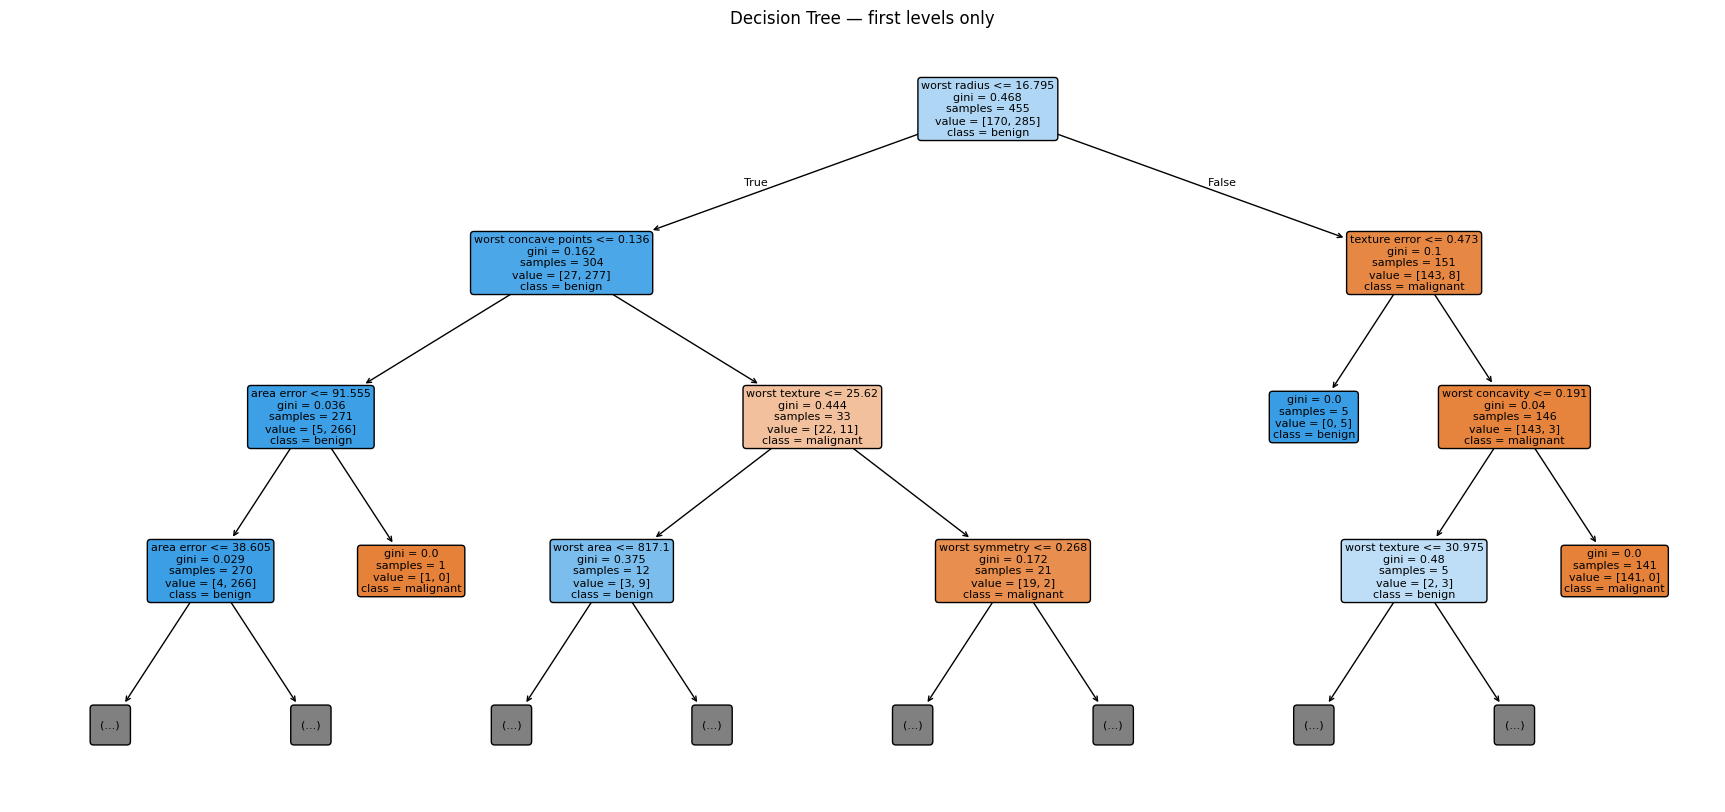

In [9]:
# Plot the top levels of the fitted tree.
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    tree_unrestricted,
    feature_names=list(X.columns),
    class_names=list(cancer.target_names),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree — first levels only")
plt.show()

## 10. Understand a Node's Decision Rule

A rule such as `worst radius <= 16.8` sends an observation left when the condition is true and right otherwise. Each subsequent rule operates only on the subset of observations that reached that node.

A tree therefore creates a set of nested, axis-aligned decision regions. Small changes in the training data can sometimes produce a different tree, especially when several candidate splits have similar quality.

In [10]:
# Inspect the learned tree's arrays and feature names.
tree_structure = tree_unrestricted.tree_

# Print a few nodes to show how the internal representation works.
for node_id in range(min(8, tree_structure.node_count)):
    feature_id = tree_structure.feature[node_id]
    if feature_id >= 0:
        feature_name = X.columns[feature_id]
        threshold = tree_structure.threshold[node_id]
        print(f"Node {node_id}: {feature_name} <= {threshold:.3f}")
    else:
        print(f"Node {node_id}: leaf")

Node 0: worst radius <= 16.795
Node 1: worst concave points <= 0.136
Node 2: area error <= 91.555
Node 3: area error <= 38.605
Node 4: smoothness error <= 0.003
Node 5: worst texture <= 26.635
Node 6: leaf
Node 7: leaf


## 11. Classification Metrics

Accuracy is the fraction of correct predictions, but it can hide poor performance on a minority class.

- **Precision:** among observations predicted positive, the fraction that are truly positive.
- **Recall / sensitivity:** among true positive observations, the fraction identified.
- **F1:** harmonic mean of precision and recall.
- **Specificity:** fraction of true negatives identified correctly.
- **ROC-AUC:** ranking quality across classification thresholds; it is not the same as accuracy.

In a medical context, metric choice depends on the consequences of false positives and false negatives. No single metric establishes clinical readiness.

In [11]:
# Evaluate the unrestricted tree with multiple classification metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred = tree_unrestricted.predict(X_test)
y_score = tree_unrestricted.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (class 1 = benign):", precision_score(y_test, y_pred))
print("Recall (class 1 = benign):", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))
print()
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Accuracy: 0.9122807017543859
Precision (class 1 = benign): 0.9558823529411765
Recall (class 1 = benign): 0.9027777777777778
F1: 0.9285714285714286
ROC-AUC: 0.9156746031746031

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



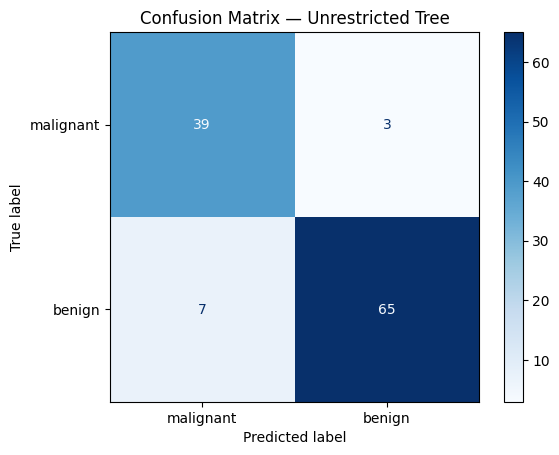

In [12]:
# Display the confusion matrix for the held-out test set.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=cancer.target_names,
    cmap="Blues"
)
plt.title("Confusion Matrix — Unrestricted Tree")
plt.show()

## 12. Overfitting and Tree Complexity

A deep tree can memorize idiosyncrasies in training observations. Common controls include:

- `max_depth`: limits how many decision levels are learned.
- `min_samples_split`: requires enough observations before splitting.
- `min_samples_leaf`: avoids leaves supported by very few observations.
- `max_leaf_nodes`: caps the number of terminal nodes.
- `ccp_alpha`: controls cost-complexity pruning; larger values generally produce smaller trees.

There is no universally optimal depth. Select complexity using cross-validation on the training data, not by choosing the configuration with the best test score.

In [13]:
# Compare several maximum depths using a fixed training/test split.
depth_results = []

for depth in [1, 2, 3, 4, 5, 7, 10, None]:
    # Build a tree with the selected depth constraint.
    candidate = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    # Fit on training data and score both splits.
    candidate.fit(X_train, y_train)
    depth_results.append({
        "max_depth": str(depth),
        "train_accuracy": candidate.score(X_train, y_train),
        "test_accuracy": candidate.score(X_test, y_test),
        "actual_depth": candidate.get_depth(),
        "leaves": candidate.get_n_leaves()
    })

depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df)

,max_depth,train_accuracy,test_accuracy,actual_depth,leaves
0,1,0.923077,0.921053,1,2
1,2,0.958242,0.894737,2,4
2,3,0.975824,0.938596,3,7
3,4,0.986813,0.938596,4,11
4,5,0.993407,0.921053,5,15
5,7,1.000000,0.912281,7,19
6,10,1.000000,0.912281,7,19
7,None,1.000000,0.912281,7,19


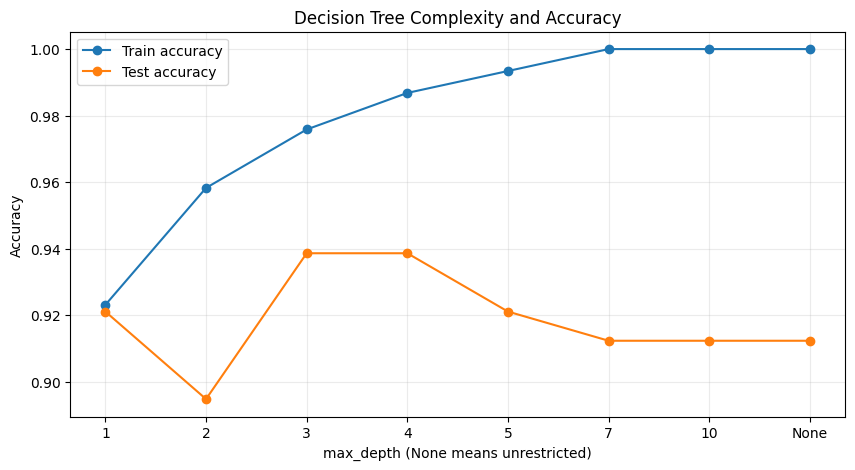

In [14]:
# Plot training and test accuracy against the tested depth settings.
positions = np.arange(len(depth_results_df))

plt.figure(figsize=(10, 5))
plt.plot(positions, depth_results_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(positions, depth_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xticks(positions, depth_results_df["max_depth"])
plt.xlabel("max_depth (None means unrestricted)")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity and Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 13. Cross-Validation and Hyperparameter Selection

Cross-validation estimates how a configuration behaves across different training/validation folds. The test set remains untouched until the end.

The following example searches a small, interpretable grid. `GridSearchCV` refits the best configuration on the complete training split by default.

In [15]:
# Search a compact set of tree hyperparameters using stratified cross-validation.
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.005]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=parameter_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Hyperparameter selection uses training data only.
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best mean CV F1:", grid_search.best_score_)
best_tree = grid_search.best_estimator_

Best parameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}
Best mean CV F1: 0.9508827216791819


In [16]:
# Evaluate the selected model once on the held-out test data.
best_pred = best_tree.predict(X_test)
best_prob = best_tree.predict_proba(X_test)[:, 1]

print("Test accuracy:", accuracy_score(y_test, best_pred))
print("Test precision:", precision_score(y_test, best_pred))
print("Test recall:", recall_score(y_test, best_pred))
print("Test F1:", f1_score(y_test, best_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, best_prob))

Test accuracy: 0.8771929824561403
Test precision: 0.953125
Test recall: 0.8472222222222222
Test F1: 0.8970588235294118
Test ROC-AUC: 0.9593253968253969


## 14. Cost-Complexity Pruning

Pruning trades some fit to the training data for a simpler tree. Minimal cost-complexity pruning considers a sequence of subtrees and penalizes the number of leaves:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

Here, \(R(T)\) is the tree's impurity-based total leaf risk (as implemented by scikit-learn), \(|T|\) is the number of leaves, and \(lpha\) controls the complexity penalty.

A larger `ccp_alpha` tends to prune more. Choose it through cross-validation rather than assuming that the smallest tree is always best.

In [17]:
# Obtain candidate pruning strengths from the training data.
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(
    X_train, y_train
)
ccp_alphas = path.ccp_alphas

# Fit a tree for each candidate alpha and record its size and training accuracy.
pruning_rows = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=float(alpha)
    )
    model.fit(X_train, y_train)
    pruning_rows.append({
        "ccp_alpha": float(alpha),
        "leaves": model.get_n_leaves(),
        "depth": model.get_depth(),
        "train_accuracy": model.score(X_train, y_train)
    })

pruning_df = pd.DataFrame(pruning_rows)
display(pruning_df.head(10))

,ccp_alpha,leaves,depth,train_accuracy
0,0.000000,19,7,1.000000
1,0.002181,15,6,0.995604
2,0.002866,12,5,0.991209
3,0.002930,11,5,0.989011
4,0.003956,10,4,0.986813
5,0.004251,9,4,0.984615
6,0.005024,8,4,0.982418
7,0.005275,7,4,0.978022
8,0.005934,6,3,0.973626
9,0.007641,5,3,0.971429


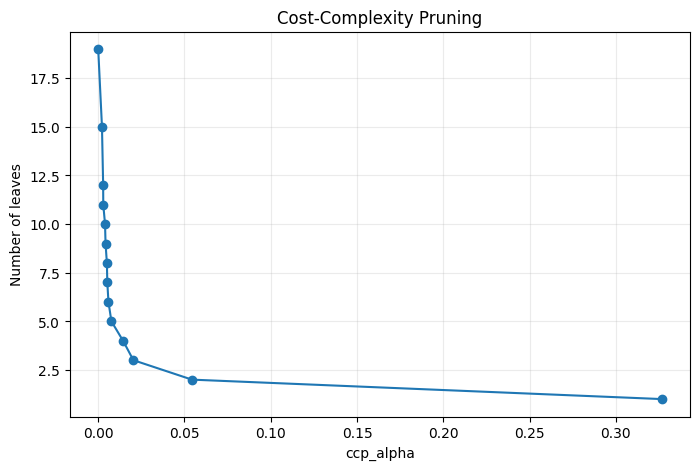

In [18]:
# Visualize how increasing pruning strength changes tree size.
plt.figure(figsize=(8, 5))
plt.plot(pruning_df["ccp_alpha"], pruning_df["leaves"], marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Number of leaves")
plt.title("Cost-Complexity Pruning")
plt.grid(alpha=0.25)
plt.show()

## 15. Feature Importance

`feature_importances_` reports each feature's normalized contribution to impurity reduction across the fitted tree. These values can help describe what the model used, but they are **not causal effects** and can be biased toward certain feature types or affected by correlated predictors.

Use permutation importance on held-out data as a complementary measure. When features are correlated, importance can be shared or distorted.

,feature,importance
20,worst radius,0.643902
27,worst concave points,0.163313
11,texture error,0.072406
21,worst texture,0.044239
26,worst concavity,0.040667
13,area error,0.023295
23,worst area,0.012177
5,mean compactness,0.000000
6,mean concavity,0.000000
4,mean smoothness,0.000000


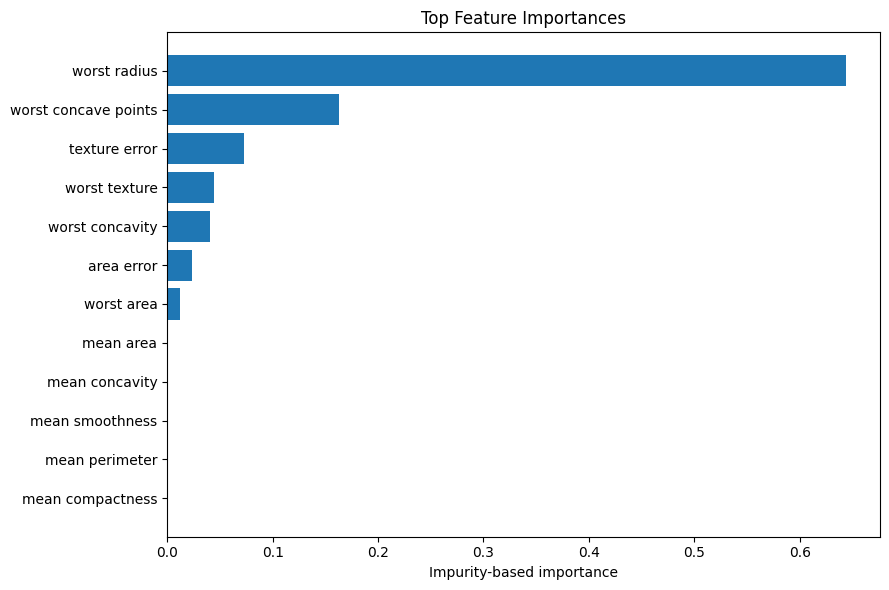

In [19]:
# Rank features by impurity-based importance for the selected tree.
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_tree.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

# Plot the most important features for readability.
top_importance = importance_df.head(12).sort_values("importance")
plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Impurity-based importance")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

In [20]:
# Calculate permutation importance on held-out data.
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    best_tree,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": X.columns,
    "mean_importance": permutation_result.importances_mean,
    "std_importance": permutation_result.importances_std
}).sort_values("mean_importance", ascending=False)

display(permutation_df.head(12))

,feature,mean_importance,std_importance
27,worst concave points,0.107650,0.034415
26,worst concavity,0.083529,0.013037
20,worst radius,0.021685,0.016302
21,worst texture,0.002619,0.003208
13,area error,0.002114,0.009564
0,mean radius,0.000000,0.000000
5,mean compactness,0.000000,0.000000
6,mean concavity,0.000000,0.000000
8,mean symmetry,0.000000,0.000000
7,mean concave points,0.000000,0.000000


## 16. Inspect a Decision Path

A single prediction can be explained as a path through the tree: each node tests a feature threshold, and the observation follows the matching branch until it reaches a leaf.

This is a local description of the model's computation, not a causal explanation of the real-world outcome.

In [21]:
# Show the decision rules followed by the first test observation.
from sklearn.tree import export_text

# Export human-readable rules for the selected tree.
rules_text = export_text(
    best_tree,
    feature_names=list(X.columns),
    max_depth=4
)
print(rules_text)

# Obtain the nodes visited by one sample.
sample = X_test.iloc[[0]]
node_indicator = best_tree.decision_path(sample)
leaf_id = best_tree.apply(sample)
visited_nodes = node_indicator.indices[
    node_indicator.indptr[0]:node_indicator.indptr[1]
]

print("Sample index:", sample.index[0])
print("Visited node IDs:", visited_nodes)
print("Leaf ID:", leaf_id[0])
print("Predicted class:", cancer.target_names[best_tree.predict(sample)[0]])

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 38.60
|   |   |   |--- worst texture <= 29.98
|   |   |   |   |--- class: 1
|   |   |   |--- worst texture >  29.98
|   |   |   |   |--- class: 1
|   |   |--- area error >  38.60
|   |   |   |--- texture error <= 1.85
|   |   |   |   |--- class: 1
|   |   |   |--- texture error >  1.85
|   |   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 27.39
|   |   |   |--- worst area <= 547.90
|   |   |   |   |--- class: 1
|   |   |   |--- worst area >  547.90
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  27.39
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0

Sample index: 256
Visited node IDs: [ 0 14 16 18]
Leaf ID: 18
Predicted class: ma

## 17. Classification Probabilities and Thresholds

`predict_proba()` returns class probabilities estimated from the class distribution in the reached leaf. These values can be coarse or poorly calibrated, particularly for small leaves.

The default class prediction uses the model's class decision rule. Changing a probability threshold changes the precision/recall trade-off and should be justified by the task. Threshold selection must be done with validation data—not the final test set.

In [22]:
# Inspect probabilities for a few test samples.
probability_preview = pd.DataFrame(
    best_tree.predict_proba(X_test.iloc[:10]),
    columns=[f"P({name})" for name in cancer.target_names],
    index=X_test.index[:10]
)
display(probability_preview)

,P(malignant),P(benign)
256,1.0,0.0
428,0.0,1.0
501,1.0,0.0
363,0.4,0.6
564,1.0,0.0
464,0.0,1.0
358,0.0,1.0
343,1.0,0.0
516,1.0,0.0
567,1.0,0.0


## 18. Regression Trees (Brief Demonstration)

A regression tree predicts a numerical target. Splits are typically selected to reduce within-node squared error or variance. Leaf predictions are usually averages of the training targets in that leaf.

The example below uses a synthetic nonlinear function so the difference from a straight-line model is visible.

In [23]:
# Generate a reproducible nonlinear regression dataset.
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

rng = np.random.default_rng(RANDOM_STATE)
X_reg = np.sort(rng.uniform(-3, 3, size=160)).reshape(-1, 1)
y_reg = np.sin(X_reg[:, 0]) + rng.normal(0, 0.15, size=len(X_reg))

# Split observations into training and test sets.
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

# Fit a shallow regression tree.
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
reg_tree.fit(Xr_train, yr_train)
yr_pred = reg_tree.predict(Xr_test)

print("Regression-tree test MSE:", mean_squared_error(yr_test, yr_pred))
print("Regression-tree test R²:", r2_score(yr_test, yr_pred))

Regression-tree test MSE: 0.04016538713799621
Regression-tree test R²: 0.9278922470842175


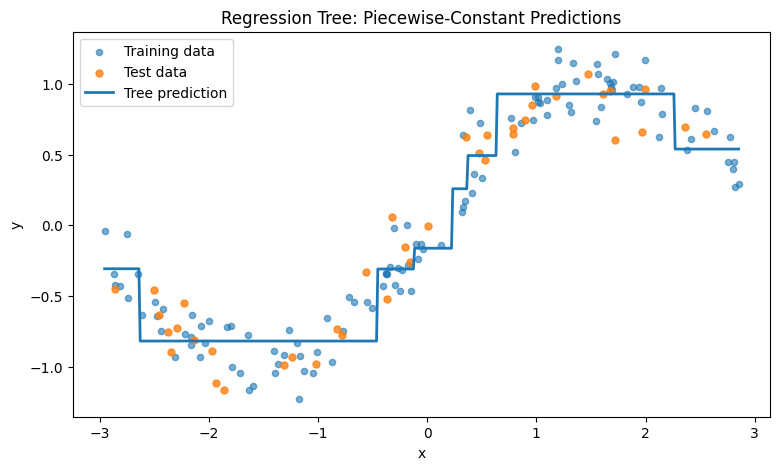

In [24]:
# Plot the true noisy observations and the tree's piecewise-constant predictions.
x_grid = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)
y_grid_pred = reg_tree.predict(x_grid)

plt.figure(figsize=(9, 5))
plt.scatter(Xr_train[:, 0], yr_train, s=20, alpha=0.6, label="Training data")
plt.scatter(Xr_test[:, 0], yr_test, s=25, alpha=0.8, label="Test data")
plt.plot(x_grid[:, 0], y_grid_pred, linewidth=2, label="Tree prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression Tree: Piecewise-Constant Predictions")
plt.legend()
plt.show()

## 19. Feature Scaling and Missing Values

- **Feature scaling:** standardization is generally unnecessary for ordinary decision trees because a monotonic rescaling of a feature preserves its order and candidate partitions.
- **Missing values:** support depends on the estimator and scikit-learn version. Do not assume every tree configuration accepts missing values. Check the documentation for the installed version or use an imputation pipeline.
- **Categorical variables:** encoding requirements depend on the estimator and version. For broad compatibility, use a suitable preprocessing pipeline; do not treat arbitrary integer category codes as meaningful numeric distances without justification.

## 20. Strengths and Limitations

### Strengths
- Captures nonlinear relationships and interactions.
- Often easy to visualize and explain at modest depth.
- Usually does not require feature scaling.
- Supports classification and regression.

### Limitations
- Deep trees can overfit.
- Small changes in data can produce different splits.
- Greedy split selection does not guarantee a globally optimal tree.
- Axis-aligned splits may need many nodes for some patterns.
- Feature importance is not causality.
- A single tree may be less predictive than ensemble methods such as Random Forests or Gradient Boosting.

A model's apparent interpretability decreases as its number of nodes and depth grow.

## 21. Common Failure Modes

- Evaluating only accuracy when class-specific errors matter.
- Tuning hyperparameters against the test set.
- Allowing an unrestricted tree and reporting training performance as generalization.
- Treating feature importance as evidence of causality.
- Ignoring class imbalance or the costs of different errors.
- Using a medical dataset example as a real diagnostic tool.
- Assuming a shallow tree is automatically fair, stable, or well-calibrated.
- Forgetting that thresholds and learned rules can be sensitive to data quality and sampling.

## 22. Reproducibility and Model Summary

Record the dataset, split strategy, random seed, model parameters, cross-validation method, metrics, and software versions. These details make the experiment easier to reproduce and audit.

In [25]:
# Summarize the selected model and relevant software versions.
import sklearn

print("scikit-learn version:", sklearn.__version__)
print("Selected parameters:", best_tree.get_params())
print("Selected tree depth:", best_tree.get_depth())
print("Selected number of leaves:", best_tree.get_n_leaves())
print("Train/test split:", len(X_train), "/", len(X_test))

scikit-learn version: 1.9.0
Selected parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Selected tree depth: 4
Selected number of leaves: 10
Train/test split: 455 / 114


## 23. Decision Tree Mastery Checklist

### Conceptual understanding
- [ ] I can explain how a Decision Tree makes predictions.
- [ ] I can identify root nodes, internal nodes, branches, and leaves.
- [ ] I can distinguish classification trees from regression trees.
- [ ] I understand why trees can represent nonlinear decision boundaries.

### Split mathematics
- [ ] I can calculate Gini impurity.
- [ ] I can explain entropy and information gain.
- [ ] I understand weighted child impurity.
- [ ] I understand that greedy split selection is local, not a guarantee of a globally optimal tree.

### Implementation
- [ ] I can train `DecisionTreeClassifier`.
- [ ] I can visualize and inspect a tree.
- [ ] I can interpret a decision path.
- [ ] I understand the purpose of `max_depth`, `min_samples_leaf`, and `ccp_alpha`.

### Evaluation and generalization
- [ ] I can interpret a confusion matrix.
- [ ] I can explain precision, recall, F1, and ROC-AUC.
- [ ] I can separate model selection from final test evaluation.
- [ ] I can recognize overfitting and use cross-validation.
- [ ] I understand the limitations of feature importance and predicted probabilities.

### Responsible use
- [ ] I do not interpret predictive associations as causal effects.
- [ ] I document the dataset, split, seed, parameters, and metrics.
- [ ] I do not use an educational example as a clinical decision system.

## Function Cheat Sheet

| Function / attribute | Purpose |
|---|---|
| `DecisionTreeClassifier()` | Create a classification tree |
| `DecisionTreeRegressor()` | Create a regression tree |
| `.fit(X, y)` | Train the estimator |
| `.predict(X)` | Predict classes or numerical values |
| `.predict_proba(X)` | Return class probabilities for supported classifiers |
| `.score(X, y)` | Default estimator score (accuracy for classifier, \(R^2\) for regressor) |
| `.get_depth()` | Return fitted tree depth |
| `.get_n_leaves()` | Return number of leaves |
| `.feature_importances_` | Impurity-based feature importance |
| `plot_tree()` | Visualize tree structure |
| `export_text()` | Export readable decision rules |
| `cost_complexity_pruning_path()` | Explore pruning alphas |
| `GridSearchCV()` | Search hyperparameters using cross-validation |
| `permutation_importance()` | Estimate importance by score drop after shuffling a feature |
| `confusion_matrix()` / `ConfusionMatrixDisplay` | Inspect classification errors |

---

